## Dataset Understanding

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#import the dataset
iris = pd.read_csv("Iris.csv")
#Let's have a look at the dataset
iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


So we have Species of Iris Flower and their Sepal Length, Sepal Width, Petal Length, Petal Width is given as the features.

In [11]:
print(iris.columns)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')


In [12]:
# Q : How many data point and features?
print(iris.shape) ##rows and columns

(150, 6)


In [13]:
#Let's remove the id column.
iris.drop('Id', axis= 1, inplace= True)

#(Q) How many data points for each class are present?
print(iris['Species'].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## ML Model

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

spliting dataset into features and target.

features=SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm

Target=Species

In [15]:
X= iris.iloc[:, 0:4] ##predictors
y= iris.iloc[:, 4] ##response variable

Converting Categorical to Numbers.

In [16]:
# Giving Numerical values to our class labels as we will have to convert them to pytorch tensors.

species_map = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
y = y.map(species_map)

Normalizing the X, so our gradient steps converge fast

In [17]:
from sklearn.preprocessing import normalize
X = normalize(X) ##x-mean/std
y = np.array(y)
y = y.astype(int)



Spliting data into Train and test parts.

In [18]:
X_train,X_test,y_train,y_test= train_test_split(X, y, test_size= 0.10, random_state= 1)
print ('X_train shape: ',X_train.shape)
print ('y_train shape: ',y_train.shape)
print ('X_test shape: ',X_test.shape)
print ('y_test shape: ',y_test.shape)

X_train shape:  (135, 4)
y_train shape:  (135,)
X_test shape:  (15, 4)
y_test shape:  (15,)


In [19]:
from torch import optim
import torch
import torch.nn as nn

Making NN for Our Problem, with 2 hidden layers and one output layer. The architecture of neural network look like this 

    Input layer: 4 Neurons
    1st Hidden layer: 27 Neurons
    2nd Hidden layer: 9 Neurons
    Output Layer: 3 Neurons

![Architecture](Capture.JPG)



We use Log NLLLoss, negative log likelihood loss. It is useful to train a classification problem with number of classes classes. we use SGD, Stochastic gradient descent optimization method to update the weights. 

In [20]:
model = nn.Sequential(nn.Linear(4, 27), ##4 predictors
                      nn.ReLU(),
                      nn.Linear(27,9), ##hidden layers
                      nn.ReLU(),
                      nn.Linear(9,3), ##3 output classes
                      nn.LogSoftmax(dim= 1))

criterion = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.003)

In [21]:
print(model) # model summary

Sequential(
  (0): Linear(in_features=4, out_features=27, bias=True)
  (1): ReLU()
  (2): Linear(in_features=27, out_features=9, bias=True)
  (3): ReLU()
  (4): Linear(in_features=9, out_features=3, bias=True)
  (5): LogSoftmax(dim=1)
)


predict function that take input and then return the predicted class

In [22]:
def predict(model, inputs):
    output = model(inputs)
    return output.data.numpy().argmax(axis= 1)

In [23]:
# making torch tensors base data that can be used for training. 
X_train = torch.from_numpy(X_train).float()
X_test = torch.from_numpy(X_test).float()
y_train = torch.from_numpy(y_train).long() 

In [24]:
epochs= 1000
batch_size= 15
n_batches = 9

costs = []
test_accuracies = []
for e in range(epochs):
    running_loss = 0
    for j in range(n_batches):
        ## taking a batch of data for training, taking only 15 entries for training at one time.
        Xbatch = X_train[j*batch_size:(j+1)*batch_size]
        Ybatch = y_train[j*batch_size:(j+1)*batch_size]
        
        ##---------------------------------------##
        #In PyTorch, we need to set the gradients to zero before starting to do backpropragation because PyTorch
        optimizer.zero_grad() # accumulates the gradients on subsequent backward passes.
        output = model(Xbatch)#forward propagation
        loss = criterion(output, Ybatch)# calculating the loss
        loss.backward()# performing backward propagation
        optimizer.step()# updating the weight
        running_loss += loss.item()# finding the loss during this step.
        ##---------------------------------------##
        
        
    Ypred = predict(model, X_test)
    
    acc = np.mean(y_test == Ypred)
    
    print("Epoch: %d, cost: %f, accuracy: %.2f" % (e, running_loss/n_batches, acc))
    
    costs.append(running_loss/n_batches)
    test_accuracies.append(acc)

Epoch: 0, cost: 1.119562, accuracy: 0.33
Epoch: 1, cost: 1.118142, accuracy: 0.33
Epoch: 2, cost: 1.116780, accuracy: 0.33
Epoch: 3, cost: 1.115471, accuracy: 0.33
Epoch: 4, cost: 1.114210, accuracy: 0.33
Epoch: 5, cost: 1.112991, accuracy: 0.33
Epoch: 6, cost: 1.111809, accuracy: 0.33
Epoch: 7, cost: 1.110661, accuracy: 0.33
Epoch: 8, cost: 1.109480, accuracy: 0.33
Epoch: 9, cost: 1.108491, accuracy: 0.33
Epoch: 10, cost: 1.107703, accuracy: 0.33
Epoch: 11, cost: 1.106945, accuracy: 0.33
Epoch: 12, cost: 1.106207, accuracy: 0.33
Epoch: 13, cost: 1.105483, accuracy: 0.33
Epoch: 14, cost: 1.104770, accuracy: 0.33
Epoch: 15, cost: 1.104081, accuracy: 0.33
Epoch: 16, cost: 1.103414, accuracy: 0.33
Epoch: 17, cost: 1.102765, accuracy: 0.33
Epoch: 18, cost: 1.102223, accuracy: 0.33
Epoch: 19, cost: 1.101750, accuracy: 0.33
Epoch: 20, cost: 1.101296, accuracy: 0.33
Epoch: 21, cost: 1.100850, accuracy: 0.33
Epoch: 22, cost: 1.100404, accuracy: 0.33
Epoch: 23, cost: 1.099964, accuracy: 0.33
Ep

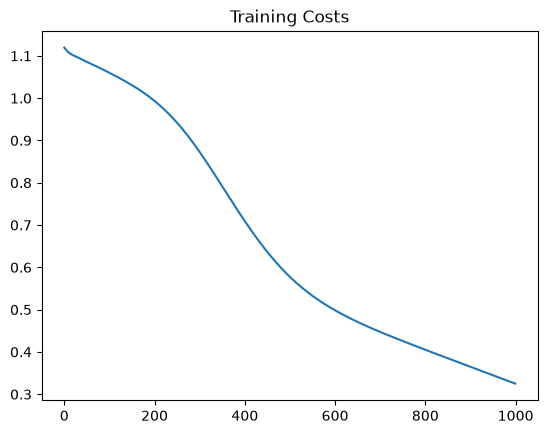

In [25]:
%matplotlib inline
plt.plot(costs)
plt.title("Training Costs")
plt.show()

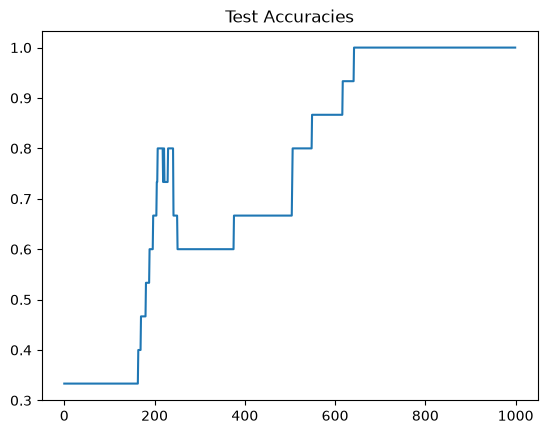

In [26]:
plt.plot(test_accuracies)
plt.title("Test Accuracies")
plt.show()

In [27]:
from sklearn.metrics import accuracy_score
ypred = predict(model, X_test)

print("Accuracy Score is {}".format(accuracy_score(y_test, ypred)))

Accuracy Score is 1.0
